# TrashNet — Clasificador binario reciclable / basura (PyTorch)

Cuarto modelo del proyecto. Mismo dataset y mismo backbone MobileNetV3Small que los
anteriores, pero el target se colapsa a **dos clases**:

| Material original | Clase binaria |
|---|---|
| cardboard, glass, metal, paper, plastic | **reciclable** |
| trash | **basura** (rechazo, no reciclable) |

El remapeo se hace en código con `target_transform`, sin duplicar ni mover imágenes.

## Lo que hace distinto a este notebook

**1. El accuracy no sirve como métrica.** Solo el 5.4% del train es `basura`. Un modelo
que siempre diga "reciclable" saca **94.27%** de accuracy en test sin detectar ni una
basura. Por eso aquí la métrica de decisión es la **average precision sobre la clase
basura** y todo se reporta con curvas precision-recall.

**2. El umbral se calibra, no se asume.** En vez de usar `argmax` (equivalente a un
umbral de 0.5), se barre el umbral sobre **validación** y se elige el operativo. El test
se evalúa una sola vez, con el umbral ya fijado.

**3. Hay una evaluación fuera de distribución.** La Parte D evalúa el modelo contra las
453 imágenes de rechazo del *Garbage Dataset* (`dataset_gd/`), que son fotos reales con
fondo y contexto, no de estudio. Responde si el modelo generaliza más allá de TrashNet.

## Baselines a batir

| Baseline | Accuracy | Recall basura | Precision basura | F1 basura |
|---|---|---|---|---|
| "todo reciclable" | 0.9427 | 0.000 | — | 0.000 |
| Modelo jerárquico, clase `gris` | — | 0.864 | 0.613 | **0.717** |

El segundo es el importante: el modelo jerárquico **ya resuelve esta tarea** de forma
implícita. Si el binario no supera F1 0.717 sobre `basura`, no justifica existir.

> **Antes de ejecutar:** cerrar cualquier kernel de TensorFlow abierto (reserva la VRAM).
>
> **Tiempo estimado en GPU (GTX 1650 SUPER): ~1 hora.**

In [1]:
import sys; print(sys.executable)

/home/benjamin-sanchez/miniconda3/envs/frameworks-ia/bin/python


In [2]:
# 1. Importaciones y configuración general

import os
import gc
import copy
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

import optuna

SEED = 42

generador = torch.Generator()


def semilla(valor=SEED):
    """
    Reinicia TODAS las fuentes de aleatoriedad del entrenamiento. Se llama al inicio de
    cada trial de Optuna y de cada reentrenamiento, para que los trials sean comparables
    entre sí y no arrastren el estado del RNG del anterior.
    """
    random.seed(valor)
    np.random.seed(valor)
    torch.manual_seed(valor)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(valor)
    generador.manual_seed(valor)


semilla()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

EPOCHS_FASE1 = 25
EPOCHS_FASE2 = 15
FINE_TUNE_LR = 1e-5

# Búsqueda con Optuna. OPTUNA_TRIALS debe ser > OPTUNA_STARTUP_TRIALS o el TPE nunca se
# usa: los primeros n_startup_trials se muestrean al azar de la distribución previa.
OPTUNA_TRIALS = 30
OPTUNA_STARTUP_TRIALS = 10
OPTUNA_EPOCHS = 8
TOP_K = 3

NUM_WORKERS = 0

# Este notebook vive en PyTorch/binario/
BASE_DIR = "../../dataset"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "validation")
TEST_DIR = os.path.join(BASE_DIR, "test")

# Evaluación fuera de distribución (Parte D). Si no existe, esa parte se salta sola.
GD_DIR = "../../dataset_gd"

ORIGINAL_CLASSES = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

# Clases binarias. El orden importa: `basura` es el índice 0 y es la CLASE DE INTERÉS.
#
# Se pone la clase rara como clase de interés a propósito. Si se usara `reciclable`,
# precision y recall saldrían ~0.98 trivialmente y no dirían nada: el 94% de las
# imágenes son reciclables.
CLASSES = ["basura", "reciclable"]
N_CLASSES = 2
IDX_BASURA = 0
IDX_RECICLABLE = 1

MAPEO_NOMBRE = {
    "cardboard": "reciclable",
    "glass": "reciclable",
    "metal": "reciclable",
    "paper": "reciclable",
    "plastic": "reciclable",
    "trash": "basura"
}

ORIGINAL_TO_BINARIO = [
    CLASSES.index(MAPEO_NOMBRE[clase]) for clase in ORIGINAL_CLASSES
]

MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

MODEL_DIR = "modelos"
RESULTS_DIR = "predicciones"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("PyTorch:", torch.__version__)
print("Optuna:", optuna.__version__)
print("Dispositivo:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU detectada:", torch.cuda.get_device_name(0))
else:
    print("GPU detectada: No; se utilizará CPU (el entrenamiento será lento)")

print("\nClases binarias:", CLASSES, f"(clase de interés: {CLASSES[IDX_BASURA]})")
print("Mapeo índice original -> índice binario:", ORIGINAL_TO_BINARIO)

PyTorch: 2.12.1+cu126
Optuna: 4.9.0
Dispositivo: cuda
GPU detectada: NVIDIA GeForce GTX 1650 SUPER

Clases binarias: ['basura', 'reciclable'] (clase de interés: basura)
Mapeo índice original -> índice binario: [1, 1, 1, 1, 1, 0]


In [3]:
# 2. Validación de la estructura del dataset original

def validar_directorio_dataset(ruta, nombre):
    if not os.path.isdir(ruta):
        raise FileNotFoundError(f"No existe el directorio {nombre}: {ruta}")

    encontradas = sorted(
        c for c in os.listdir(ruta) if os.path.isdir(os.path.join(ruta, c))
    )
    faltantes = sorted(set(ORIGINAL_CLASSES) - set(encontradas))
    if faltantes:
        raise ValueError(f"Faltan clases en {nombre}: {faltantes}")

    print(f"{nombre}: {encontradas}")


validar_directorio_dataset(TRAIN_DIR, "Train")
validar_directorio_dataset(VALID_DIR, "Validation")
validar_directorio_dataset(TEST_DIR, "Test")

hay_gd = os.path.isdir(os.path.join(GD_DIR, "trash"))
if hay_gd:
    n_gd = len([
        f for f in os.listdir(os.path.join(GD_DIR, "trash"))
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ])
    print(f"\nGarbage Dataset encontrado: {n_gd} imágenes de rechazo (Parte D activa)")
else:
    print(f"\nNo se encontró {GD_DIR}/trash — la Parte D se saltará")

Train: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Validation: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Test: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Garbage Dataset encontrado: 453 imágenes de rechazo (Parte D activa)


In [4]:
# 3. Conteo por clase original y por clase binaria

def contar_imagenes_por_clase(ruta):
    ext = (".jpg", ".jpeg", ".png", ".webp")
    return {
        clase: sum(
            f.lower().endswith(ext)
            for f in os.listdir(os.path.join(ruta, clase))
        )
        for clase in ORIGINAL_CLASSES
    }


def reagrupar(conteos):
    agrupados = {clase: 0 for clase in CLASSES}
    for clase_original, cantidad in conteos.items():
        agrupados[MAPEO_NOMBRE[clase_original]] += cantidad
    return agrupados


train_count_original = contar_imagenes_por_clase(TRAIN_DIR)
valid_count_original = contar_imagenes_por_clase(VALID_DIR)
test_count_original = contar_imagenes_por_clase(TEST_DIR)

train_count = reagrupar(train_count_original)
valid_count = reagrupar(valid_count_original)
test_count = reagrupar(test_count_original)

print("CONTEO BINARIO")
print(f"{'split':<12}{'basura':>9}{'reciclable':>13}{'total':>8}{'% basura':>11}{'ratio':>10}")

for nombre, conteo in [("train", train_count), ("validation", valid_count),
                       ("test", test_count)]:
    neg, pos = conteo["basura"], conteo["reciclable"]
    total = neg + pos
    print(
        f"{nombre:<12}{neg:>9}{pos:>13}{total:>8}"
        f"{100 * neg / total:>10.1f}%{pos / neg:>9.1f}:1"
    )

# El número que hay que tener presente todo el rato
BASELINE_TRIVIAL = test_count["reciclable"] / (test_count["basura"] + test_count["reciclable"])

print(
    f"\nOJO: un modelo que SIEMPRE diga 'reciclable' saca "
    f"{BASELINE_TRIVIAL:.2%} de accuracy en test"
)
print("y detecta 0 basuras. El accuracy no es una métrica útil aquí.")

CONTEO BINARIO
split          basura   reciclable   total   % basura     ratio
train              95         1671    1766       5.4%     17.6:1
validation         20          357     377       5.3%     17.9:1
test               22          362     384       5.7%     16.5:1

OJO: un modelo que SIEMPRE diga 'reciclable' saca 94.27% de accuracy en test
y detecta 0 basuras. El accuracy no es una métrica útil aquí.


In [5]:
# 4. Pesos de clase
#    peso_i = n_muestras / (n_clases * conteo_i), la fórmula de
#    sklearn compute_class_weight("balanced")

conteos = np.array([train_count[c] for c in CLASSES], dtype=np.float64)
class_weights_array = conteos.sum() / (N_CLASSES * conteos)

class_weights_tensor = torch.tensor(
    class_weights_array, dtype=torch.float32, device=DEVICE
)

print("Pesos por clase:")
for i, clase in enumerate(CLASSES):
    print(f"  {i} - {clase:<12}: {class_weights_array[i]:.4f}")

Pesos por clase:
  0 - basura      : 9.2947
  1 - reciclable  : 0.5284


In [6]:
# 5. Data augmentation (igual que en los notebooks anteriores)

def crear_data_augmentation():
    return [
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(degrees=36),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.90, 1.10)),
        transforms.ColorJitter(contrast=0.10),
    ]


normalizacion = [transforms.ToTensor(), transforms.Normalize(MEAN, STD)]

train_tf = transforms.Compose(
    [transforms.Resize(IMG_SIZE), *crear_data_augmentation(), *normalizacion]
)

eval_tf = transforms.Compose([transforms.Resize(IMG_SIZE), *normalizacion])

In [7]:
# 6. Importación del dataset y remapeo binario

def remapear_a_binario(indice_original):
    return ORIGINAL_TO_BINARIO[indice_original]


def cargar_dataset(ruta, transform):
    dataset = datasets.ImageFolder(
        ruta, transform=transform, target_transform=remapear_a_binario
    )
    assert dataset.classes == ORIGINAL_CLASSES, (
        f"Orden de clases inesperado en {ruta}: {dataset.classes}"
    )
    return dataset


train_ds = cargar_dataset(TRAIN_DIR, train_tf)
valid_ds = cargar_dataset(VALID_DIR, eval_tf)
test_ds = cargar_dataset(TEST_DIR, eval_tf)

comun = dict(
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=NUM_WORKERS > 0
)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=generador, **comun
)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, **comun)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **comun)

# Comprobación del remapeo contra los conteos de la celda 3
etiquetas_test = np.array([remapear_a_binario(y) for _, y in test_ds.samples])
conteo_remapeado = {
    clase: int((etiquetas_test == i).sum()) for i, clase in enumerate(CLASSES)
}
assert conteo_remapeado == test_count, f"remapeo mal: {conteo_remapeado} vs {test_count}"

print(f"Train: {len(train_ds)} | Validation: {len(valid_ds)} | Test: {len(test_ds)}")
print("Remapeo verificado sobre test:", conteo_remapeado)

Train: 1766 | Validation: 377 | Test: 384
Remapeo verificado sobre test: {'basura': 22, 'reciclable': 362}


## Métricas para clasificación desbalanceada

Todo implementado a mano con NumPy porque el entorno no tiene scikit-learn.

La diferencia con los notebooks anteriores es la **curva precision-recall** y la
**average precision (AP)**. Bajo desbalance fuerte la curva ROC es engañosamente
optimista: como el 94% de las imágenes son negativas para la clase `basura`, la tasa de
falsos positivos se mantiene baja aunque el modelo genere muchos falsos positivos en
términos absolutos. La curva PR no tiene ese problema porque su eje de precision sí
penaliza los falsos positivos frente a los verdaderos positivos.

La AP se calcula igual que `sklearn.metrics.average_precision_score`: suma de
`(R_n − R_{n−1}) · P_n`, sin interpolación.

In [8]:
# 7. Métricas binarias (sin scikit-learn)

def confusion_matrix(y_true, y_pred, n=N_CLASSES):
    cm = np.zeros((n, n), dtype=int)
    for real, predicho in zip(y_true, y_pred):
        cm[real][predicho] += 1
    return cm


def metricas_por_clase(cm):
    metricas = {}
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)
              if (precision + recall) > 0 else 0.0)
        metricas[i] = {
            "precision": float(precision), "recall": float(recall),
            "f1": float(f1), "support": int(cm[i, :].sum())
        }
    return metricas


def accuracy_score(y_true, y_pred):
    return float((np.asarray(y_true) == np.asarray(y_pred)).mean())


def balanced_accuracy(y_true, y_pred, n=N_CLASSES):
    """Media de los recalls por clase. Es el accuracy 'justo' bajo desbalance:
    el modelo trivial 'todo reciclable' saca 0.5, no 0.94."""
    cm = confusion_matrix(y_true, y_pred, n)
    m = metricas_por_clase(cm)
    return float(np.mean([m[i]["recall"] for i in range(n)]))


def macro(metricas, clave):
    return float(np.mean([m[clave] for m in metricas.values()]))


def precision_recall_curve(y_true_bin, y_score):
    """
    Curva precision-recall de la clase de interés y su average precision.

    y_true_bin: 1 donde la etiqueta real es la clase de interés, 0 en el resto.
    y_score:    probabilidad predicha de la clase de interés.

    Devuelve (precision, recall, umbrales, ap).
    """
    y_true_bin = np.asarray(y_true_bin).astype(int)
    y_score = np.asarray(y_score, dtype=float)

    P = int(y_true_bin.sum())
    if P == 0:
        return np.array([1.0]), np.array([0.0]), np.array([]), 0.0

    orden = np.argsort(-y_score, kind="mergesort")
    y = y_true_bin[orden]
    s = y_score[orden]

    tp = np.cumsum(y)
    fp = np.cumsum(1 - y)

    # con scores empatados solo vale el último punto del grupo
    ultimos = np.r_[np.diff(s) != 0, True]
    tp, fp, umbrales = tp[ultimos], fp[ultimos], s[ultimos]

    precision = tp / (tp + fp)
    recall = tp / P

    # AP = suma de (R_n - R_{n-1}) * P_n, igual que sklearn
    ap = float(np.sum(np.diff(np.r_[0.0, recall]) * precision))

    return precision, recall, umbrales, ap


def roc_curve(y_true_bin, y_score):
    """ROC one-vs-rest y su AUC por regla del trapecio."""
    y_true_bin = np.asarray(y_true_bin).astype(int)
    y_score = np.asarray(y_score, dtype=float)

    P = int(y_true_bin.sum())
    N = len(y_true_bin) - P
    if P == 0 or N == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0]), 0.5

    orden = np.argsort(-y_score, kind="mergesort")
    y = y_true_bin[orden]
    s = y_score[orden]

    tp = np.cumsum(y)
    fp = np.cumsum(1 - y)
    ultimos = np.r_[np.diff(s) != 0, True]

    tpr = np.r_[0.0, tp[ultimos] / P, 1.0]
    fpr = np.r_[0.0, fp[ultimos] / N, 1.0]

    _trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return fpr, tpr, abs(float(_trapz(tpr, fpr)))


def label_binarize(y, n_clases=N_CLASSES):
    return np.eye(n_clases, dtype=int)[np.asarray(y)]


def predecir_con_umbral(p_basura, umbral):
    """Predice `basura` cuando su probabilidad alcanza el umbral."""
    return np.where(np.asarray(p_basura) >= umbral, IDX_BASURA, IDX_RECICLABLE)


def metricas_en_umbral(y_true, p_basura, umbral):
    y_pred = predecir_con_umbral(p_basura, umbral)
    cm = confusion_matrix(y_true, y_pred)
    m = metricas_por_clase(cm)
    return {
        "umbral": float(umbral),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy(y_true, y_pred),
        "precision_basura": m[IDX_BASURA]["precision"],
        "recall_basura": m[IDX_BASURA]["recall"],
        "f1_basura": m[IDX_BASURA]["f1"],
        "f1_macro": macro(m, "f1"),
        "cm": cm
    }


def classification_report(y_true, y_pred, target_names=CLASSES, digits=4):
    cm = confusion_matrix(y_true, y_pred, len(target_names))
    metricas = metricas_por_clase(cm)
    total = int(cm.sum())
    ancho = max(len(n) for n in target_names) + 2

    cabecera = (f"{'':>{ancho}}{'precision':>12}{'recall':>12}"
                f"{'f1-score':>12}{'support':>12}")
    lineas = [cabecera, ""]

    for i, nombre in enumerate(target_names):
        m = metricas[i]
        lineas.append(
            f"{nombre:>{ancho}}{m['precision']:>12.{digits}f}"
            f"{m['recall']:>12.{digits}f}{m['f1']:>12.{digits}f}{m['support']:>12d}"
        )

    lineas.append("")
    lineas.append(
        f"{'accuracy':>{ancho}}{'':>12}{'':>12}"
        f"{accuracy_score(y_true, y_pred):>12.{digits}f}{total:>12d}"
    )
    lineas.append(
        f"{'macro avg':>{ancho}}{macro(metricas, 'precision'):>12.{digits}f}"
        f"{macro(metricas, 'recall'):>12.{digits}f}"
        f"{macro(metricas, 'f1'):>12.{digits}f}{total:>12d}"
    )

    pesos = np.array([metricas[i]["support"] for i in range(len(target_names))])
    lineas.append(
        f"{'weighted avg':>{ancho}}"
        + "".join(
            f"{float(np.average([metricas[i][k] for i in range(len(target_names))], weights=pesos)):>12.{digits}f}"
            for k in ("precision", "recall", "f1")
        )
        + f"{total:>12d}"
    )

    return "\n".join(lineas)


# Comprobación rápida de que la AP está bien implementada:
# con un ranking perfecto AP = 1, y con scores constantes AP = prevalencia.
_y = np.array([1, 1, 0, 0, 0, 0])
assert abs(precision_recall_curve(_y, np.array([.9, .8, .3, .2, .1, .0]))[3] - 1.0) < 1e-9
assert abs(precision_recall_curve(_y, np.full(6, 0.5))[3] - 2 / 6) < 1e-9
print("Métricas listas (AP verificada con dos casos conocidos)")

Métricas listas (AP verificada con dos casos conocidos)


## Parte A — Modelo binario sin Optuna

Hiperparámetros manuales, los mismos que sirvieron de baseline en los notebooks
anteriores: 128 neuronas, dropout 0.35, Adam con lr 3e-4, y fine-tuning de los últimos
3 bloques a lr 1e-5.

**El EarlyStopping NO monitoriza `val_accuracy`.** Con un 5% de positivos, la accuracy de
validación se queda clavada en ~0.95 desde la primera época y no distingue un modelo
bueno de uno que ignora la clase `basura`. Aquí se monitoriza la **average precision
sobre `basura`**, que es la métrica que de verdad mide lo que interesa.

In [9]:
# 8. Constructor del modelo

class TrashNetMobileNetV3(nn.Module):
    """MobileNetV3Small -> GlobalAvgPool -> Dense(units, relu) -> Dropout -> Dense(2).

    La softmax no va en el modelo: CrossEntropyLoss la aplica sobre los logits. Se
    mantienen 2 salidas en vez de un logit único para poder reutilizar tal cual las
    métricas de los otros notebooks, que son genéricas en el número de clases.
    """

    def __init__(self, dense_units, dropout_rate, n_classes=N_CLASSES):
        super().__init__()
        base = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)

        self.features = base.features
        n_features = base.classifier[0].in_features

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_features, dense_units),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(dense_units, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)


def congelar_backbone(model):
    for p in model.features.parameters():
        p.requires_grad = False


def descongelar_ultimos_bloques(model, n_bloques=3):
    """Fase 2. Las BatchNorm quedan congeladas (parámetros y estadísticas)."""
    for p in model.features.parameters():
        p.requires_grad = False

    for bloque in model.features[-n_bloques:]:
        for p in bloque.parameters():
            p.requires_grad = True

    for m in model.features.modules():
        if isinstance(m, nn.BatchNorm2d):
            for p in m.parameters():
                p.requires_grad = False


def construir_optimizador(model, optimizer_name, learning_rate):
    entrenables = [p for p in model.parameters() if p.requires_grad]
    if optimizer_name.lower() == "adam":
        return torch.optim.Adam(entrenables, lr=learning_rate)
    if optimizer_name.lower() == "rmsprop":
        return torch.optim.RMSprop(entrenables, lr=learning_rate)
    raise ValueError(f"Optimizador no soportado: {optimizer_name}")


def construir_modelo(dense_units, dropout_rate, optimizer_name, learning_rate,
                     nombre_modelo, usar_class_weight=True):
    model = TrashNetMobileNetV3(dense_units, dropout_rate).to(DEVICE)
    model.nombre = nombre_modelo
    congelar_backbone(model)

    optimizer = construir_optimizador(model, optimizer_name, learning_rate)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights_tensor if usar_class_weight else None
    )
    return model, optimizer, criterion


def resumen_modelo(model):
    total = sum(p.numel() for p in model.parameters())
    entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Modelo: {getattr(model, 'nombre', model.__class__.__name__)}")
    print(f"Parámetros totales:     {total:,}")
    print(f"Parámetros entrenables: {entrenables:,}")
    print(f"Parámetros congelados:  {total - entrenables:,}")

In [10]:
# 8b. Bucle de entrenamiento
#     Reproduce model.fit + EarlyStopping + ReduceLROnPlateau de Keras, pero
#     monitorizando average precision sobre `basura` en vez de val_accuracy.

def limpiar_memoria():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def entrenar_epoca(model, loader, criterion, optimizer):
    model.train()
    model.features.eval()   # backbone siempre en inferencia (BatchNorm congeladas)

    perdida, aciertos, total = 0.0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        perdida += loss.item() * labels.size(0)
        aciertos += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return perdida / total, aciertos / total


@torch.no_grad()
def evaluar(model, loader, criterion=None):
    """Devuelve loss, accuracy, balanced accuracy, AP sobre basura, y_true y y_prob."""
    model.eval()

    perdida, total = 0.0, 0
    y_true_all, y_prob_all = [], []

    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        labels_dev = labels.to(DEVICE, non_blocking=True)

        outputs = model(images)
        if criterion is not None:
            perdida += criterion(outputs, labels_dev).item() * labels.size(0)
        total += labels.size(0)

        y_prob_all.append(torch.softmax(outputs, dim=1).cpu().numpy())
        y_true_all.append(labels.numpy())

    y_true = np.concatenate(y_true_all)
    y_prob = np.concatenate(y_prob_all)
    y_pred = y_prob.argmax(1)

    p_basura = y_prob[:, IDX_BASURA]
    _, _, _, ap = precision_recall_curve((y_true == IDX_BASURA).astype(int), p_basura)

    return {
        "loss": perdida / total if criterion is not None else float("nan"),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy(y_true, y_pred),
        "ap": ap,
        "y_true": y_true,
        "y_prob": y_prob
    }


def entrenar(model, optimizer, criterion, epochs, patience_es, patience_lr, min_lr,
             verbose=1):
    """
    history con: loss, accuracy, val_loss, val_accuracy, val_balanced_accuracy, val_ap.

    - EarlyStopping sobre val_ap (maximizar) con restore_best_weights
    - ReduceLROnPlateau sobre val_loss
    """
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=patience_lr, min_lr=min_lr
    )

    history = {k: [] for k in ["loss", "accuracy", "val_loss", "val_accuracy",
                               "val_balanced_accuracy", "val_ap"]}

    mejor_ap = -np.inf
    mejores_pesos = copy.deepcopy(model.state_dict())
    sin_mejora = 0
    inicio = time.time()

    for epoca in range(epochs):
        lr_antes = optimizer.param_groups[0]["lr"]

        train_loss, train_acc = entrenar_epoca(model, train_loader, criterion, optimizer)
        val = evaluar(model, valid_loader, criterion)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val["loss"])
        history["val_accuracy"].append(val["accuracy"])
        history["val_balanced_accuracy"].append(val["balanced_accuracy"])
        history["val_ap"].append(val["ap"])

        scheduler.step(val["loss"])
        lr_despues = optimizer.param_groups[0]["lr"]

        if val["ap"] > mejor_ap:
            mejor_ap = val["ap"]
            mejores_pesos = copy.deepcopy(model.state_dict())
            sin_mejora = 0
        else:
            sin_mejora += 1

        if verbose:
            print(
                f"Época {epoca + 1:02d}/{epochs} | loss {train_loss:.4f} "
                f"acc {train_acc:.4f} | val_loss {val['loss']:.4f} "
                f"val_acc {val['accuracy']:.4f} bal_acc {val['balanced_accuracy']:.4f} "
                f"AP {val['ap']:.4f} | lr {lr_despues:.2e}"
            )
            if lr_despues < lr_antes:
                print(f"  ReduceLROnPlateau: {lr_antes:.2e} -> {lr_despues:.2e}")

        if sin_mejora >= patience_es:
            if verbose:
                print(f"EarlyStopping en la época {epoca + 1}: "
                      f"{patience_es} épocas sin mejorar la AP")
            break

    model.load_state_dict(mejores_pesos)

    if verbose:
        print(f"Mejor AP en validación: {mejor_ap:.4f} "
              f"(pesos restaurados) — {time.time() - inicio:.1f}s")

    return history

In [11]:
# 9. Modelo base sin Optuna — Fase 1

limpiar_memoria()
semilla()

BASE_DENSE_UNITS = 128
BASE_DROPOUT = 0.35
BASE_LR = 3e-4
BASE_OPTIMIZER = "adam"

model_base, optimizer_base, criterion = construir_modelo(
    dense_units=BASE_DENSE_UNITS,
    dropout_rate=BASE_DROPOUT,
    optimizer_name=BASE_OPTIMIZER,
    learning_rate=BASE_LR,
    nombre_modelo="trashnet_binario_sin_optuna"
)

resumen_modelo(model_base)

Modelo: trashnet_binario_sin_optuna
Parámetros totales:     1,001,122
Parámetros entrenables: 74,114
Parámetros congelados:  927,008


In [12]:
# 10. Entrenamiento del modelo base — Fase 1

history_base_fase1 = entrenar(
    model_base, optimizer_base, criterion,
    epochs=EPOCHS_FASE1, patience_es=6, patience_lr=3, min_lr=1e-6, verbose=1
)

Época 01/25 | loss 0.6136 acc 0.8596 | val_loss 0.3521 val_acc 0.9178 bal_acc 0.6970 AP 0.3761 | lr 3.00e-04
Época 02/25 | loss 0.4961 acc 0.8556 | val_loss 0.4320 val_acc 0.8435 bal_acc 0.8230 AP 0.3853 | lr 3.00e-04
Época 03/25 | loss 0.4228 acc 0.8516 | val_loss 0.4198 val_acc 0.8249 bal_acc 0.8368 AP 0.4206 | lr 3.00e-04
Época 04/25 | loss 0.3697 acc 0.8613 | val_loss 0.3251 val_acc 0.8780 bal_acc 0.8648 AP 0.4900 | lr 3.00e-04
Época 05/25 | loss 0.3346 acc 0.8743 | val_loss 0.3111 val_acc 0.8833 bal_acc 0.8676 AP 0.5205 | lr 3.00e-04
Época 06/25 | loss 0.3023 acc 0.8862 | val_loss 0.3834 val_acc 0.8223 bal_acc 0.8590 AP 0.5634 | lr 3.00e-04
Época 07/25 | loss 0.2920 acc 0.8873 | val_loss 0.2442 val_acc 0.9045 bal_acc 0.8788 AP 0.5700 | lr 3.00e-04
Época 08/25 | loss 0.2682 acc 0.8969 | val_loss 0.2819 val_acc 0.8966 bal_acc 0.8982 AP 0.5851 | lr 3.00e-04
Época 09/25 | loss 0.2497 acc 0.9026 | val_loss 0.2628 val_acc 0.8966 bal_acc 0.8982 AP 0.6199 | lr 3.00e-04
Época 10/25 | loss 

In [13]:
# 11. Modelo base — Fase 2: fine-tuning

descongelar_ultimos_bloques(model_base, n_bloques=3)
resumen_modelo(model_base)

optimizer_base_fase2 = construir_optimizador(model_base, "adam", FINE_TUNE_LR)

history_base_fase2 = entrenar(
    model_base, optimizer_base_fase2, criterion,
    epochs=EPOCHS_FASE2, patience_es=5, patience_lr=2, min_lr=1e-7, verbose=1
)

Modelo: trashnet_binario_sin_optuna
Parámetros totales:     1,001,122
Parámetros entrenables: 712,610
Parámetros congelados:  288,512
Época 01/15 | loss 0.1379 acc 0.9570 | val_loss 0.1828 val_acc 0.9363 bal_acc 0.8956 AP 0.6978 | lr 1.00e-05
Época 02/15 | loss 0.1631 acc 0.9558 | val_loss 0.2113 val_acc 0.9284 bal_acc 0.9150 AP 0.6964 | lr 1.00e-05
Época 03/15 | loss 0.1461 acc 0.9383 | val_loss 0.1945 val_acc 0.9337 bal_acc 0.9178 AP 0.6992 | lr 1.00e-05
Época 04/15 | loss 0.1319 acc 0.9536 | val_loss 0.1900 val_acc 0.9337 bal_acc 0.9178 AP 0.6973 | lr 5.00e-06
  ReduceLROnPlateau: 1.00e-05 -> 5.00e-06
Época 05/15 | loss 0.1450 acc 0.9405 | val_loss 0.1832 val_acc 0.9337 bal_acc 0.8942 AP 0.6976 | lr 5.00e-06
Época 06/15 | loss 0.1435 acc 0.9462 | val_loss 0.1885 val_acc 0.9337 bal_acc 0.8942 AP 0.6987 | lr 5.00e-06
Época 07/15 | loss 0.1268 acc 0.9558 | val_loss 0.1712 val_acc 0.9363 bal_acc 0.8956 AP 0.7007 | lr 5.00e-06
Época 08/15 | loss 0.1334 acc 0.9519 | val_loss 0.1788 val_ac

In [14]:
# 12. Guardar el modelo sin Optuna

RUTA_MODELO_BASE = os.path.join(MODEL_DIR, "trashnet_binario_sin_optuna.pt")

torch.save({
    "state_dict": model_base.state_dict(),
    "dense_units": BASE_DENSE_UNITS,
    "dropout_rate": BASE_DROPOUT,
    "classes": CLASSES,
    "mapeo": MAPEO_NOMBRE,
    "img_size": IMG_SIZE
}, RUTA_MODELO_BASE)

print("Modelo sin Optuna guardado en:", RUTA_MODELO_BASE)

Modelo sin Optuna guardado en: modelos/trashnet_binario_sin_optuna.pt


## Parte B — Búsqueda de hiperparámetros con Optuna

Misma metodología corregida que en el notebook jerárquico, con un cambio importante:
**la métrica que se optimiza es la average precision sobre `basura`**, no la accuracy.
Optimizar accuracy aquí llevaría a Optuna directo al modelo trivial que dice "reciclable"
siempre.

Las cuatro correcciones respecto a la versión ingenua:

1. **30 trials, no 10.** `TPESampler` tiene `n_startup_trials=10` por defecto: con solo
   10 trials todos son aleatorios y el TPE nunca llega a usarse. Aquí hay 10 de arranque
   y 20 informados.
2. **El baseline se encola como trial 0** con `enqueue_trial`, para que la búsqueda tenga
   contra qué compararse.
3. **`semilla()` al inicio de cada trial**, para que no arrastren el estado del RNG.
4. **El top-3 se reentrena a presupuesto completo** y se elige con eso, en vez de confiar
   en el ranking de 8 épocas.

La selección usa siempre validación. El test no se toca hasta la Parte C.

In [15]:
# 13. Función objetivo

def objective(trial):
    semilla()
    limpiar_memoria()

    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.20, 0.50, step=0.05)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["adam", "rmsprop"])

    model_trial, optimizer_trial, criterion_trial = construir_modelo(
        dense_units=dense_units,
        dropout_rate=dropout_rate,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
        nombre_modelo=f"trial_{trial.number}"
    )

    history = entrenar(
        model_trial, optimizer_trial, criterion_trial,
        epochs=OPTUNA_EPOCHS, patience_es=3, patience_lr=2, min_lr=1e-7, verbose=0
    )

    mejor_ap = float(max(history["val_ap"]))

    trial.set_user_attr("epochs_executed", len(history["val_ap"]))
    trial.set_user_attr("val_balanced_accuracy", float(max(history["val_balanced_accuracy"])))

    print(f"Trial {trial.number:02d} | AP={mejor_ap:.4f} | {trial.params}")

    del model_trial, optimizer_trial
    limpiar_memoria()

    return mejor_ap

In [16]:
# 14. Ejecutar el estudio

PARAMS_BASELINE = {
    "dense_units": BASE_DENSE_UNITS,
    "dropout_rate": BASE_DROPOUT,
    "learning_rate": BASE_LR,
    "optimizer": BASE_OPTIMIZER
}

sampler = optuna.samplers.TPESampler(
    seed=SEED, n_startup_trials=OPTUNA_STARTUP_TRIALS
)

study = optuna.create_study(
    direction="maximize", sampler=sampler,
    study_name="TrashNet_Binario_Optuna_PyTorch"
)

study.enqueue_trial(PARAMS_BASELINE)

print("Trial 0 encolado con la configuración del baseline:")
print(PARAMS_BASELINE)
print(f"\n{OPTUNA_TRIALS} trials: {OPTUNA_STARTUP_TRIALS} de arranque aleatorio + "
      f"{OPTUNA_TRIALS - OPTUNA_STARTUP_TRIALS} informados por el TPE")
print(f"Métrica optimizada: average precision sobre '{CLASSES[IDX_BASURA]}'")
print(f"{OPTUNA_EPOCHS} épocas por trial (solo fase 1)\n")

study.optimize(objective, n_trials=OPTUNA_TRIALS)

valor_baseline = study.trials[0].value

print("\nMejor trial de la búsqueda:", study.best_trial.number)
print(f"Mejor AP: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")
print(f"\nBaseline (trial 0): AP {valor_baseline:.4f}")
print(f"Diferencia del mejor sobre el baseline: {study.best_value - valor_baseline:+.4f}")

[I 2026-08-10 21:41:17,103] A new study created in memory with name: TrashNet_Binario_Optuna_PyTorch


Trial 0 encolado con la configuración del baseline:
{'dense_units': 128, 'dropout_rate': 0.35, 'learning_rate': 0.0003, 'optimizer': 'adam'}

30 trials: 10 de arranque aleatorio + 20 informados por el TPE
Métrica optimizada: average precision sobre 'basura'
8 épocas por trial (solo fase 1)



[I 2026-08-10 21:42:28,002] Trial 0 finished with value: 0.5850633197485093 and parameters: {'dense_units': 128, 'dropout_rate': 0.35, 'learning_rate': 0.0003, 'optimizer': 'adam'}. Best is trial 0 with value: 0.5850633197485093.


Trial 00 | AP=0.5851 | {'dense_units': 128, 'dropout_rate': 0.35, 'learning_rate': 0.0003, 'optimizer': 'adam'}


[I 2026-08-10 21:43:36,062] Trial 1 finished with value: 0.3521159569787068 and parameters: {'dense_units': 128, 'dropout_rate': 0.4, 'learning_rate': 2.0513382630874486e-05, 'optimizer': 'adam'}. Best is trial 0 with value: 0.5850633197485093.


...

Trial 27 | AP=0.7193 | {'dense_units': 256, 'dropout_rate': 0.35000000000000003, 'learning_rate': 0.0004014161549869656, 'optimizer': 'adam'}


[I 2026-08-10 22:13:41,461] Trial 28 finished with value: 0.6403620207559315 and parameters: {'dense_units': 256, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.00024355361613385168, 'optimizer': 'adam'}. Best is trial 18 with value: 0.8011244721010031.


Trial 28 | AP=0.6404 | {'dense_units': 256, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.00024355361613385168, 'optimizer': 'adam'}


[I 2026-08-10 22:14:52,573] Trial 29 finished with value: 0.7697252649858506 and parameters: {'dense_units': 256, 'dropout_rate': 0.25, 'learning_rate': 0.000713979692348794, 'optimizer': 'adam'}. Best is trial 18 with value: 0.8011244721010031.


Trial 29 | AP=0.7697 | {'dense_units': 256, 'dropout_rate': 0.25, 'learning_rate': 0.000713979692348794, 'optimizer': 'adam'}

Mejor trial de la búsqueda: 18
Mejor AP: 0.8011

Mejores hiperparámetros:
  dense_units: 256
  dropout_rate: 0.30000000000000004
  learning_rate: 0.0009886008984971674
  optimizer: adam

Baseline (trial 0): AP 0.5851
Diferencia del mejor sobre el baseline: +0.2161


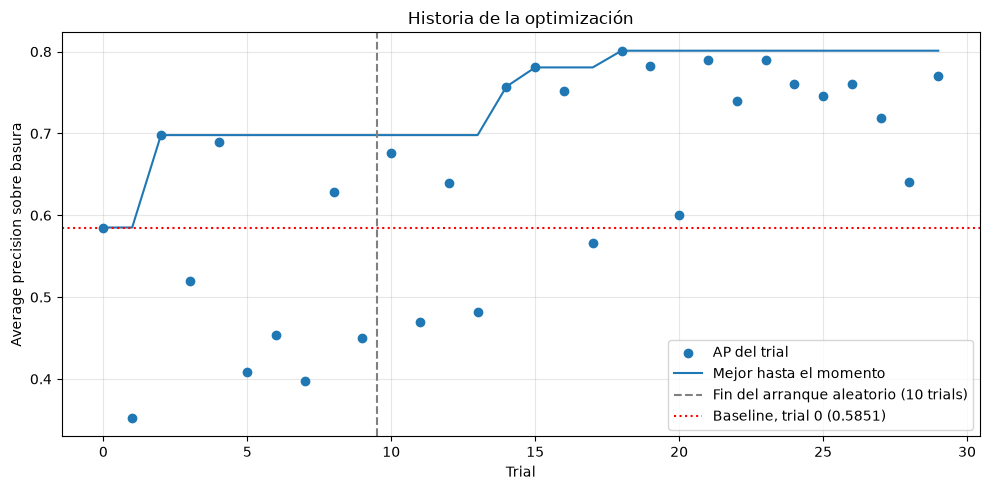

Arranque aleatorio (10 trials): media 0.5182 | máximo 0.6980
Informados por TPE (20 trials): media 0.7012 | máximo 0.8011

Mejora del TPE sobre el azar en la media: +0.1830


In [17]:
# 14b. Historia de la optimización
#      Si los trials informados se concentran por encima de los aleatorios, el TPE
#      está aportando; si no, la búsqueda equivale a random search.

completos = [t for t in study.trials
             if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None]

numeros = [t.number for t in completos]
valores = [t.value for t in completos]

plt.figure(figsize=(10, 5))
plt.scatter(numeros, valores, label="AP del trial", zorder=3)
plt.plot(numeros, np.maximum.accumulate(valores), label="Mejor hasta el momento", zorder=2)
plt.axvline(OPTUNA_STARTUP_TRIALS - 0.5, linestyle="--", color="gray",
            label=f"Fin del arranque aleatorio ({OPTUNA_STARTUP_TRIALS} trials)")
plt.axhline(valor_baseline, linestyle=":", color="red",
            label=f"Baseline, trial 0 ({valor_baseline:.4f})")
plt.xlabel("Trial")
plt.ylabel(f"Average precision sobre {CLASSES[IDX_BASURA]}")
plt.title("Historia de la optimización")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "bin_optuna_historia.png"), dpi=120)
plt.show()

aleatorios = [t.value for t in completos if t.number < OPTUNA_STARTUP_TRIALS]
informados = [t.value for t in completos if t.number >= OPTUNA_STARTUP_TRIALS]

print(f"Arranque aleatorio ({len(aleatorios)} trials): "
      f"media {np.mean(aleatorios):.4f} | máximo {np.max(aleatorios):.4f}")
if informados:
    print(f"Informados por TPE ({len(informados)} trials): "
          f"media {np.mean(informados):.4f} | máximo {np.max(informados):.4f}")
    print(f"\nMejora del TPE sobre el azar en la media: "
          f"{np.mean(informados) - np.mean(aleatorios):+.4f}")

In [18]:
# 15. Tabla de todos los trials

def fuente_trial(trial):
    if trial.number == 0:
        return "baseline"
    return "azar" if trial.number < OPTUNA_STARTUP_TRIALS else "tpe"


filas = sorted(study.trials,
               key=lambda t: (t.value if t.value is not None else -np.inf),
               reverse=True)

encabezado = (f"{'number':>7}{'AP':>9}{'fuente':>10}{'dense':>8}"
              f"{'dropout':>9}{'learning_rate':>16}{'optimizer':>11}{'state':>11}")
print(encabezado)
print("-" * len(encabezado))

for t in filas:
    valor = f"{t.value:.4f}" if t.value is not None else "-"
    print(f"{t.number:>7}{valor:>9}{fuente_trial(t):>10}"
          f"{t.params.get('dense_units', '-'):>8}"
          f"{t.params.get('dropout_rate', float('nan')):>9.2f}"
          f"{t.params.get('learning_rate', float('nan')):>16.8f}"
          f"{t.params.get('optimizer', '-'):>11}{t.state.name:>11}")

 number       AP    fuente   dense  dropout   learning_rate  optimizer      state
---------------------------------------------------------------------------------
     18   0.8011       tpe     256     0.30      0.00098860       adam   COMPLETE
     23   0.7903       tpe     256     0.25      0.00096119       adam   COMPLETE
     21   0.7895       tpe     256     0.25      0.00099466       adam   COMPLETE
     19   0.7823       tpe     256     0.25      0.00097795       adam   COMPLETE
     15   0.7807       tpe     256     0.25      0.00098117       adam   COMPLETE
     29   0.7697       tpe     256     0.25      0.00071398       adam   COMPLETE
     26   0.7606       tpe     256     0.25      0.00074236       adam   COMPLETE
     24   0.7605       tpe     256     0.30      0.00064839       adam   COMPLETE
     14   0.7572       tpe     256     0.30      0.00059239    rmsprop   COMPLETE
     16   0.7519       tpe     256     0.30      0.00053650    rmsprop   COMPLETE
     25   0.7456

In [19]:
# 16. Reentrenamiento del top-K a presupuesto completo
#
#     El ranking de la búsqueda se midió con pocas épocas de solo fase 1. En vez de
#     confiar en él, se reentrenan los TOP_K mejores con el presupuesto completo y se
#     elige con eso. La selección usa VALIDACIÓN; el test no se toca.

candidatos = sorted(
    [t for t in study.trials
     if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None],
    key=lambda t: t.value, reverse=True
)[:TOP_K]

print(f"Reentrenando los {len(candidatos)} mejores a presupuesto completo "
      f"({EPOCHS_FASE1} + {EPOCHS_FASE2} épocas cada uno)")

resultados_topk = []

for puesto, trial in enumerate(candidatos, start=1):
    print()
    print("=" * 76)
    print(f"[{puesto}/{len(candidatos)}] Trial {trial.number} ({fuente_trial(trial)}) "
          f"— AP en la búsqueda: {trial.value:.4f}")
    print(f"    {trial.params}")
    print("=" * 76)

    semilla()
    limpiar_memoria()

    model_c, optimizer_c, criterion_c = construir_modelo(
        dense_units=trial.params["dense_units"],
        dropout_rate=trial.params["dropout_rate"],
        optimizer_name=trial.params["optimizer"],
        learning_rate=trial.params["learning_rate"],
        nombre_modelo=f"candidato_trial_{trial.number}"
    )

    print("\n-- Fase 1: backbone congelado")
    h1 = entrenar(model_c, optimizer_c, criterion_c, epochs=EPOCHS_FASE1,
                  patience_es=6, patience_lr=3, min_lr=1e-7, verbose=1)

    print("\n-- Fase 2: fine-tuning de los últimos 3 bloques")
    descongelar_ultimos_bloques(model_c, n_bloques=3)
    optimizer_c2 = construir_optimizador(model_c, trial.params["optimizer"], FINE_TUNE_LR)

    h2 = entrenar(model_c, optimizer_c2, criterion_c, epochs=EPOCHS_FASE2,
                  patience_es=5, patience_lr=2, min_lr=1e-7, verbose=1)

    ap_completo = max(h1["val_ap"] + h2["val_ap"])

    resultados_topk.append({
        "trial": trial.number,
        "fuente": fuente_trial(trial),
        "params": dict(trial.params),
        "ap_busqueda": float(trial.value),
        "ap_completo": float(ap_completo),
        "history_fase1": h1,
        "history_fase2": h2,
        "state_dict": {k: v.detach().cpu().clone()
                       for k, v in model_c.state_dict().items()}
    })

    print(f"\n=> Trial {trial.number}: AP a presupuesto completo = {ap_completo:.4f} "
          f"(en la búsqueda era {trial.value:.4f})")

    del model_c, optimizer_c, optimizer_c2
    limpiar_memoria()

print("\nReentrenamiento del top-K terminado.")

Reentrenando los 3 mejores a presupuesto completo (25 + 15 épocas cada uno)

[1/3] Trial 18 (tpe) — AP en la búsqueda: 0.8011
    {'dense_units': 256, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.0009886008984971674, 'optimizer': 'adam'}

-- Fase 1: backbone congelado
Época 01/25 | loss 0.5276 acc 0.8454 | val_loss 0.4068 val_acc 0.8143 bal_acc 0.8312 AP 0.4792 | lr 9.89e-04
Época 02/25 | loss 0.4347 acc 0.8414 | val_loss 0.6762 val_acc 0.6658 bal_acc 0.8235 AP 0.4432 | lr 9.89e-04
Época 03/25 | loss 0.3025 acc 0.8749 | val_loss 0.2343 val_acc 0.9045 bal_acc 0.9024 AP 0.5865 | lr 9.89e-04
Época 04/25 | loss 0.3173 acc 0.8794 | val_loss 0.2486 val_acc 0.8966 bal_acc 0.8746 AP 0.5944 | lr 9.89e-04
Época 05/25 | loss 0.2508 acc 0.8901 | val_loss 0.1662 val_acc 0.9469 bal_acc 0.9248 AP 0.6963 | lr 9.89e-04
Época 06/25 | loss 0.2206 acc 0.9151 | val_loss 0.2298 val_acc 0.9125 bal_acc 0.9066 AP 0.7409 | lr 9.89e-04
Época 07/25 | loss 0.1917 acc 0.9292 | val_loss 0.1959 val_acc 0.9

In [20]:
# 17. Selección del ganador

ranking = sorted(resultados_topk, key=lambda r: r["ap_completo"], reverse=True)
ganador = ranking[0]

encabezado = (f"{'trial':>7}{'fuente':>10}{'AP búsqueda':>14}{'AP completo':>14}"
              f"{'dense':>8}{'dropout':>9}{'lr':>14}{'optimizer':>11}")
print("TOP-K REENTRENADO A PRESUPUESTO COMPLETO")
print(encabezado)
print("-" * len(encabezado))

for r in ranking:
    p = r["params"]
    print(f"{r['trial']:>7}{r['fuente']:>10}{r['ap_busqueda']:>14.4f}"
          f"{r['ap_completo']:>14.4f}{p['dense_units']:>8}{p['dropout_rate']:>9.2f}"
          f"{p['learning_rate']:>14.8f}{p['optimizer']:>11}")

orden_busqueda = [r["trial"] for r in resultados_topk]
orden_completo = [r["trial"] for r in ranking]

print()
if orden_busqueda != orden_completo:
    print("El ranking CAMBIÓ al reentrenar a presupuesto completo:")
    print(f"  por AP de búsqueda:      {orden_busqueda}")
    print(f"  por presupuesto completo: {orden_completo}")
else:
    print(f"El ranking se mantuvo: {orden_completo}")

BEST_DENSE_UNITS = ganador["params"]["dense_units"]
BEST_DROPOUT = ganador["params"]["dropout_rate"]
BEST_LR = ganador["params"]["learning_rate"]
BEST_OPTIMIZER = ganador["params"]["optimizer"]
BEST_TRIAL = ganador["trial"]

model_optuna = TrashNetMobileNetV3(BEST_DENSE_UNITS, BEST_DROPOUT).to(DEVICE)
model_optuna.load_state_dict(ganador["state_dict"])
model_optuna.nombre = "trashnet_binario_optuna"
descongelar_ultimos_bloques(model_optuna, n_bloques=3)   # deja los flags como en fase 2

history_optuna_fase1 = ganador["history_fase1"]
history_optuna_fase2 = ganador["history_fase2"]

print(f"\nGANADOR: trial {BEST_TRIAL} ({ganador['fuente']})")
print(f"  dense_units {BEST_DENSE_UNITS} | dropout {BEST_DROPOUT} | "
      f"lr {BEST_LR:.8f} | {BEST_OPTIMIZER}")
print(f"  AP a presupuesto completo: {ganador['ap_completo']:.4f}")

if ganador["params"] == PARAMS_BASELINE:
    print("\nAVISO: el ganador ES la configuración del baseline. 'Sin Optuna' y "
          "'Con Optuna'\ncomparten hiperparámetros, así que la comparación mide solo "
          "la varianza\nentre dos corridas del mismo modelo.")

print()
resumen_modelo(model_optuna)

TOP-K REENTRENADO A PRESUPUESTO COMPLETO
  trial    fuente   AP búsqueda   AP completo   dense  dropout            lr  optimizer
---------------------------------------------------------------------------------------
     21       tpe        0.7895        0.8126     256     0.25    0.00099466       adam
     23       tpe        0.7903        0.8045     256     0.25    0.00096119       adam
     18       tpe        0.8011        0.8011     256     0.30    0.00098860       adam

El ranking CAMBIÓ al reentrenar a presupuesto completo:
  por AP de búsqueda:      [18, 23, 21]
  por presupuesto completo: [21, 23, 18]

GANADOR: trial 21 (tpe)
  dense_units 256 | dropout 0.25 | lr 0.00099466 | adam
  AP a presupuesto completo: 0.8126

Modelo: trashnet_binario_optuna
Parámetros totales:     1,075,234
Parámetros entrenables: 786,722
Parámetros congelados:  288,512


In [21]:
# 18. Guardar el modelo ganador

RUTA_MODELO_OPTUNA = os.path.join(MODEL_DIR, "trashnet_binario_optuna.pt")

torch.save({
    "state_dict": model_optuna.state_dict(),
    "dense_units": BEST_DENSE_UNITS,
    "dropout_rate": BEST_DROPOUT,
    "learning_rate": BEST_LR,
    "optimizer": BEST_OPTIMIZER,
    "trial": BEST_TRIAL,
    "ap_validacion": ganador["ap_completo"],
    "classes": CLASSES,
    "mapeo": MAPEO_NOMBRE,
    "img_size": IMG_SIZE
}, RUTA_MODELO_OPTUNA)

print("Modelo con Optuna guardado en:", RUTA_MODELO_OPTUNA)

Modelo con Optuna guardado en: modelos/trashnet_binario_optuna.pt


## Parte C — Calibración del umbral y evaluación

Aquí no se vuelve a entrenar. El orden importa y es el siguiente:

1. Se obtienen las probabilidades de **validación** y se elige el umbral con ellas.
2. Solo entonces se evalúa el **test**, una única vez, con el umbral ya fijado.

Usar `argmax` equivale a fijar el umbral en 0.5 sin justificación. Con clases tan
desbalanceadas el umbral óptimo casi nunca está en 0.5, así que calibrarlo suele dar más
mejora que cualquier ajuste de hiperparámetros.

In [22]:
# 19. Probabilidades de validación y test para ambos modelos

val_base = evaluar(model_base, valid_loader)
val_optuna = evaluar(model_optuna, valid_loader)

test_base = evaluar(model_base, test_loader)
test_optuna = evaluar(model_optuna, test_loader)

y_val = val_base["y_true"]
y_test = test_base["y_true"]

assert np.array_equal(y_val, val_optuna["y_true"])
assert np.array_equal(y_test, test_optuna["y_true"])

# Probabilidad de la clase de interés
p_val_base = val_base["y_prob"][:, IDX_BASURA]
p_val_optuna = val_optuna["y_prob"][:, IDX_BASURA]
p_test_base = test_base["y_prob"][:, IDX_BASURA]
p_test_optuna = test_optuna["y_prob"][:, IDX_BASURA]

# Vector binario de la clase de interés
b_val = (y_val == IDX_BASURA).astype(int)
b_test = (y_test == IDX_BASURA).astype(int)

print(f"Validación: {len(y_val)} imágenes, {b_val.sum()} de basura")
print(f"Test:       {len(y_test)} imágenes, {b_test.sum()} de basura")
print(f"\nAP en validación — sin Optuna {val_base['ap']:.4f} | "
      f"con Optuna {val_optuna['ap']:.4f}")
print(f"AP en test       — sin Optuna {test_base['ap']:.4f} | "
      f"con Optuna {test_optuna['ap']:.4f}")

Validación: 377 imágenes, 20 de basura
Test:       384 imágenes, 22 de basura

AP en validación — sin Optuna 0.7225 | con Optuna 0.8126
AP en test       — sin Optuna 0.7593 | con Optuna 0.7977


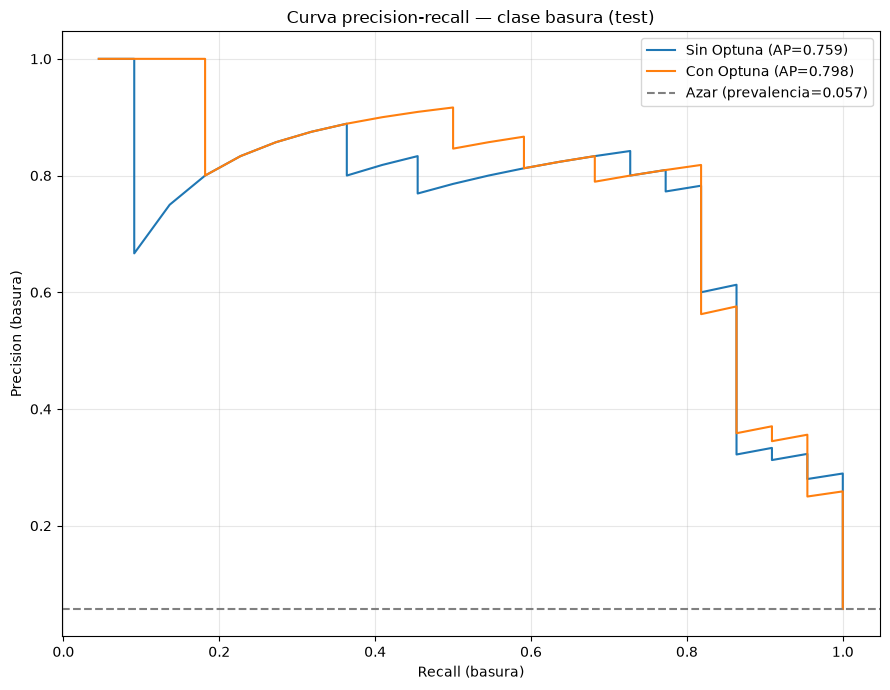

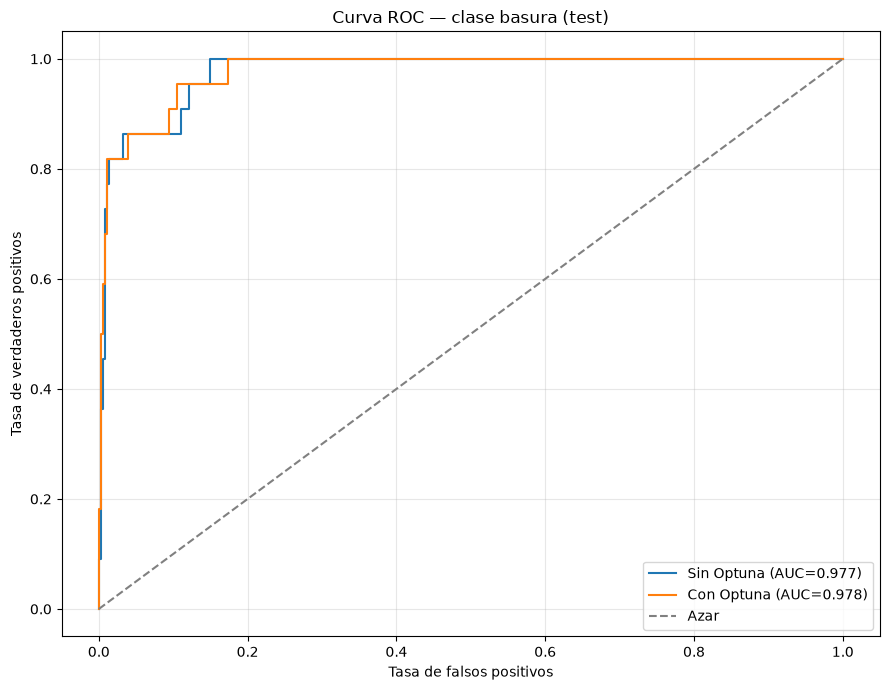

Comparar los dos números del mismo modelo: la AUC es mucho más alta que la AP.
Es el efecto del desbalance, no una contradicción — ver la nota de la Parte C.


In [23]:
# 20. Curvas precision-recall y ROC (sobre test)
#     La PR es la que hay que mirar: la ROC infla el resultado bajo desbalance fuerte.

prev = b_test.mean()

plt.figure(figsize=(9, 7))
for nombre, p in [("Sin Optuna", p_test_base), ("Con Optuna", p_test_optuna)]:
    precision, recall, _, ap = precision_recall_curve(b_test, p)
    plt.plot(recall, precision, label=f"{nombre} (AP={ap:.3f})")

plt.axhline(prev, linestyle="--", color="gray",
            label=f"Azar (prevalencia={prev:.3f})")
plt.xlabel("Recall (basura)")
plt.ylabel("Precision (basura)")
plt.title("Curva precision-recall — clase basura (test)")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "bin_pr_test.png"), dpi=120)
plt.show()

plt.figure(figsize=(9, 7))
for nombre, p in [("Sin Optuna", p_test_base), ("Con Optuna", p_test_optuna)]:
    fpr, tpr, auc = roc_curve(b_test, p)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — clase basura (test)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "bin_roc_test.png"), dpi=120)
plt.show()

print("Comparar los dos números del mismo modelo: la AUC es mucho más alta que la AP.")
print("Es el efecto del desbalance, no una contradicción — ver la nota de la Parte C.")

BARRIDO DEL UMBRAL SOBRE VALIDACIÓN (modelo con Optuna)

Umbral de F1 máximo: 0.837
  precision 0.7500 | recall 0.7500 | F1 0.7500 | bal_acc 0.8680

Umbral con recall >= 0.90: 0.310
  precision 0.3913 | recall 0.9000 | F1 0.5455

Para comparar, el umbral por defecto 0.500 (argmax):
  precision 0.4722 | recall 0.8500 | F1 0.6071

Ganancia de F1 por calibrar el umbral: +0.1429


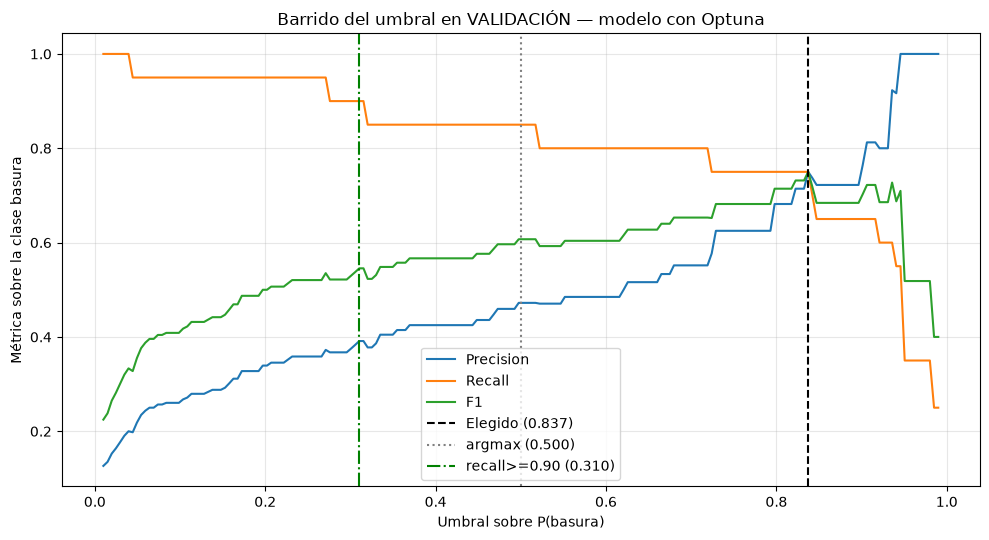


Umbral del modelo sin Optuna (calibrado igual): 0.763


In [24]:
# 21. Barrido del umbral SOBRE VALIDACIÓN y elección del punto de operación

RECALL_MINIMO = 0.90   # criterio de producto: no dejar pasar basura al reciclaje

def barrer_umbrales(y_true, p_basura, n=200):
    umbrales = np.linspace(0.01, 0.99, n)
    return umbrales, [metricas_en_umbral(y_true, p_basura, u) for u in umbrales]


def elegir_umbral(y_true, p_basura, recall_minimo=RECALL_MINIMO):
    """Devuelve (umbral de F1 máximo, umbral con recall>=minimo y mejor precision)."""
    umbrales, metricas = barrer_umbrales(y_true, p_basura)

    idx_f1 = int(np.argmax([m["f1_basura"] for m in metricas]))

    validos = [i for i, m in enumerate(metricas) if m["recall_basura"] >= recall_minimo]
    idx_rec = max(validos, key=lambda i: metricas[i]["precision_basura"]) if validos else None

    return umbrales, metricas, idx_f1, idx_rec


umbrales, met_val, idx_f1, idx_rec = elegir_umbral(y_val, p_val_optuna)

UMBRAL = float(umbrales[idx_f1])          # punto de operación elegido
m_f1 = met_val[idx_f1]

print("BARRIDO DEL UMBRAL SOBRE VALIDACIÓN (modelo con Optuna)")
print(f"\nUmbral de F1 máximo: {UMBRAL:.3f}")
print(f"  precision {m_f1['precision_basura']:.4f} | recall {m_f1['recall_basura']:.4f} "
      f"| F1 {m_f1['f1_basura']:.4f} | bal_acc {m_f1['balanced_accuracy']:.4f}")

if idx_rec is not None:
    m_rec = met_val[idx_rec]
    print(f"\nUmbral con recall >= {RECALL_MINIMO:.2f}: {umbrales[idx_rec]:.3f}")
    print(f"  precision {m_rec['precision_basura']:.4f} | recall {m_rec['recall_basura']:.4f} "
          f"| F1 {m_rec['f1_basura']:.4f}")
else:
    print(f"\nNingún umbral alcanza recall >= {RECALL_MINIMO:.2f} en validación")

m_05 = metricas_en_umbral(y_val, p_val_optuna, 0.5)
print(f"\nPara comparar, el umbral por defecto 0.500 (argmax):")
print(f"  precision {m_05['precision_basura']:.4f} | recall {m_05['recall_basura']:.4f} "
      f"| F1 {m_05['f1_basura']:.4f}")
print(f"\nGanancia de F1 por calibrar el umbral: "
      f"{m_f1['f1_basura'] - m_05['f1_basura']:+.4f}")

plt.figure(figsize=(10, 5.5))
for clave, etiqueta in [("precision_basura", "Precision"),
                        ("recall_basura", "Recall"),
                        ("f1_basura", "F1")]:
    plt.plot(umbrales, [m[clave] for m in met_val], label=etiqueta)

plt.axvline(UMBRAL, linestyle="--", color="black", label=f"Elegido ({UMBRAL:.3f})")
plt.axvline(0.5, linestyle=":", color="gray", label="argmax (0.500)")
if idx_rec is not None:
    plt.axvline(umbrales[idx_rec], linestyle="-.", color="green",
                label=f"recall>={RECALL_MINIMO:.2f} ({umbrales[idx_rec]:.3f})")

plt.xlabel("Umbral sobre P(basura)")
plt.ylabel("Métrica sobre la clase basura")
plt.title("Barrido del umbral en VALIDACIÓN — modelo con Optuna")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "bin_umbral_validacion.png"), dpi=120)
plt.show()

# El baseline necesita su propio umbral, calibrado igual
umbrales_b, met_val_b, idx_f1_b, _ = elegir_umbral(y_val, p_val_base)
UMBRAL_BASE = float(umbrales_b[idx_f1_b])
print(f"\nUmbral del modelo sin Optuna (calibrado igual): {UMBRAL_BASE:.3f}")

In [25]:
# 22. Evaluación en TEST con el umbral fijado (primera y única vez que se toca)

res_base = metricas_en_umbral(y_test, p_test_base, UMBRAL_BASE)
res_optuna = metricas_en_umbral(y_test, p_test_optuna, UMBRAL)
res_argmax = metricas_en_umbral(y_test, p_test_optuna, 0.5)

# Baselines de referencia
JERARQUICO_GRIS = {"precision_basura": 0.6129, "recall_basura": 0.8636, "f1_basura": 0.7170}

filas = [
    ("Trivial 'todo reciclable'", {
        "accuracy": BASELINE_TRIVIAL, "balanced_accuracy": 0.5,
        "precision_basura": 0.0, "recall_basura": 0.0, "f1_basura": 0.0}),
    ("Jerárquico (clase gris)", {
        "accuracy": float("nan"), "balanced_accuracy": float("nan"), **JERARQUICO_GRIS}),
    ("Binario sin Optuna", res_base),
    ("Binario con Optuna (argmax)", res_argmax),
    ("Binario con Optuna (umbral)", res_optuna),
]

encabezado = (f"{'modelo':<30}{'accuracy':>10}{'bal.acc':>10}"
              f"{'prec.':>9}{'recall':>9}{'F1':>9}")
print("RESULTADOS EN TEST — clase de interés: basura")
print(encabezado)
print("-" * len(encabezado))

for nombre, r in filas:
    acc = f"{r['accuracy']:.4f}" if r["accuracy"] == r["accuracy"] else "—"
    bal = f"{r['balanced_accuracy']:.4f}" if r["balanced_accuracy"] == r["balanced_accuracy"] else "—"
    print(f"{nombre:<30}{acc:>10}{bal:>10}"
          f"{r['precision_basura']:>9.4f}{r['recall_basura']:>9.4f}{r['f1_basura']:>9.4f}")

print(f"\nAP en test — sin Optuna {test_base['ap']:.4f} | con Optuna {test_optuna['ap']:.4f}")

mejora = res_optuna["f1_basura"] - JERARQUICO_GRIS["f1_basura"]
print(f"\nDiferencia de F1 frente al jerárquico: {mejora:+.4f}")
print("El modelo binario justifica existir." if mejora > 0 else
      "El modelo binario NO supera al jerárquico: sale más barato colapsar sus 4 salidas.")

RESULTADOS EN TEST — clase de interés: basura
modelo                          accuracy   bal.acc    prec.   recall       F1
-----------------------------------------------------------------------------
Trivial 'todo reciclable'         0.9427    0.5000   0.0000   0.0000   0.0000
Jerárquico (clase gris)                —         —   0.6129   0.8636   0.7170
Binario sin Optuna                0.9740    0.8795   0.7727   0.7727   0.7727
Binario con Optuna (argmax)       0.9479    0.9083   0.5278   0.8636   0.6552
Binario con Optuna (umbral)       0.9792    0.9036   0.8182   0.8182   0.8182

AP en test — sin Optuna 0.7593 | con Optuna 0.7977

Diferencia de F1 frente al jerárquico: +0.1012
El modelo binario justifica existir.


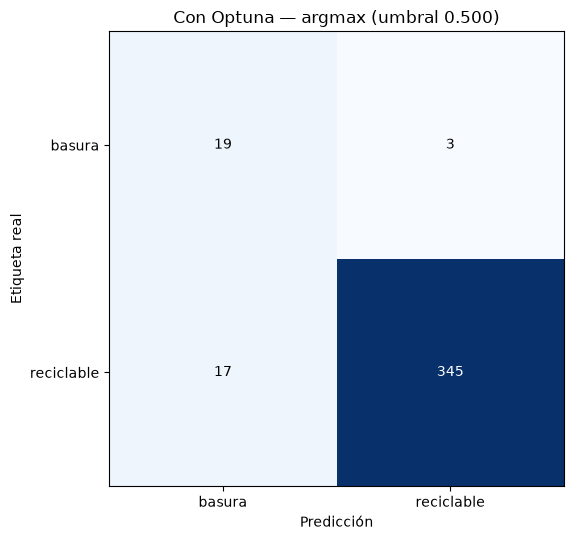

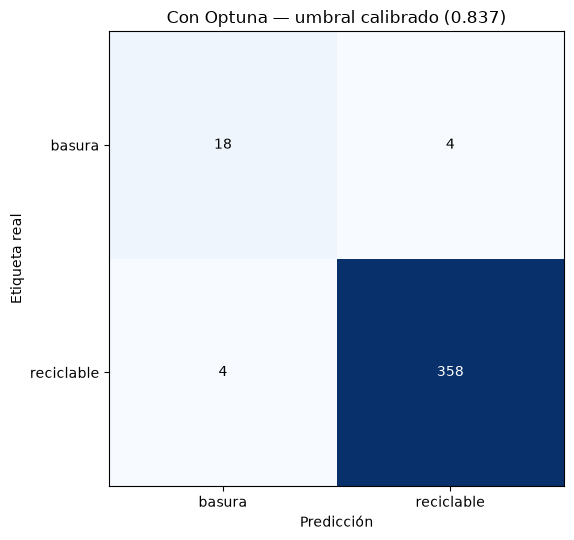

REPORTE DE CLASIFICACIÓN — con Optuna, umbral calibrado
               precision      recall    f1-score     support

      basura      0.8182      0.8182      0.8182          22
  reciclable      0.9890      0.9890      0.9890         362

    accuracy                              0.9792         384
   macro avg      0.9036      0.9036      0.9036         384
weighted avg      0.9792      0.9792      0.9792         384


In [26]:
# 23. Matrices de confusión en test

def graficar_matriz_confusion(cm, titulo, archivo=None):
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.imshow(cm, interpolation="nearest", cmap="Blues")

    ax.set_xticks(range(N_CLASSES))
    ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(CLASSES)
    ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Etiqueta real")

    umbral_color = cm.max() / 2.0
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            ax.text(j, i, f"{cm[i, j]:d}", ha="center", va="center",
                    color="white" if cm[i, j] > umbral_color else "black")

    plt.title(titulo)
    plt.tight_layout()
    if archivo:
        plt.savefig(os.path.join(RESULTS_DIR, archivo), dpi=120)
    plt.show()


graficar_matriz_confusion(
    res_argmax["cm"], f"Con Optuna — argmax (umbral 0.500)",
    "bin_matriz_confusion_argmax.png"
)
graficar_matriz_confusion(
    res_optuna["cm"], f"Con Optuna — umbral calibrado ({UMBRAL:.3f})",
    "bin_matriz_confusion_umbral.png"
)

print("REPORTE DE CLASIFICACIÓN — con Optuna, umbral calibrado")
print("=" * 62)
print(classification_report(y_test, predecir_con_umbral(p_test_optuna, UMBRAL), CLASSES))

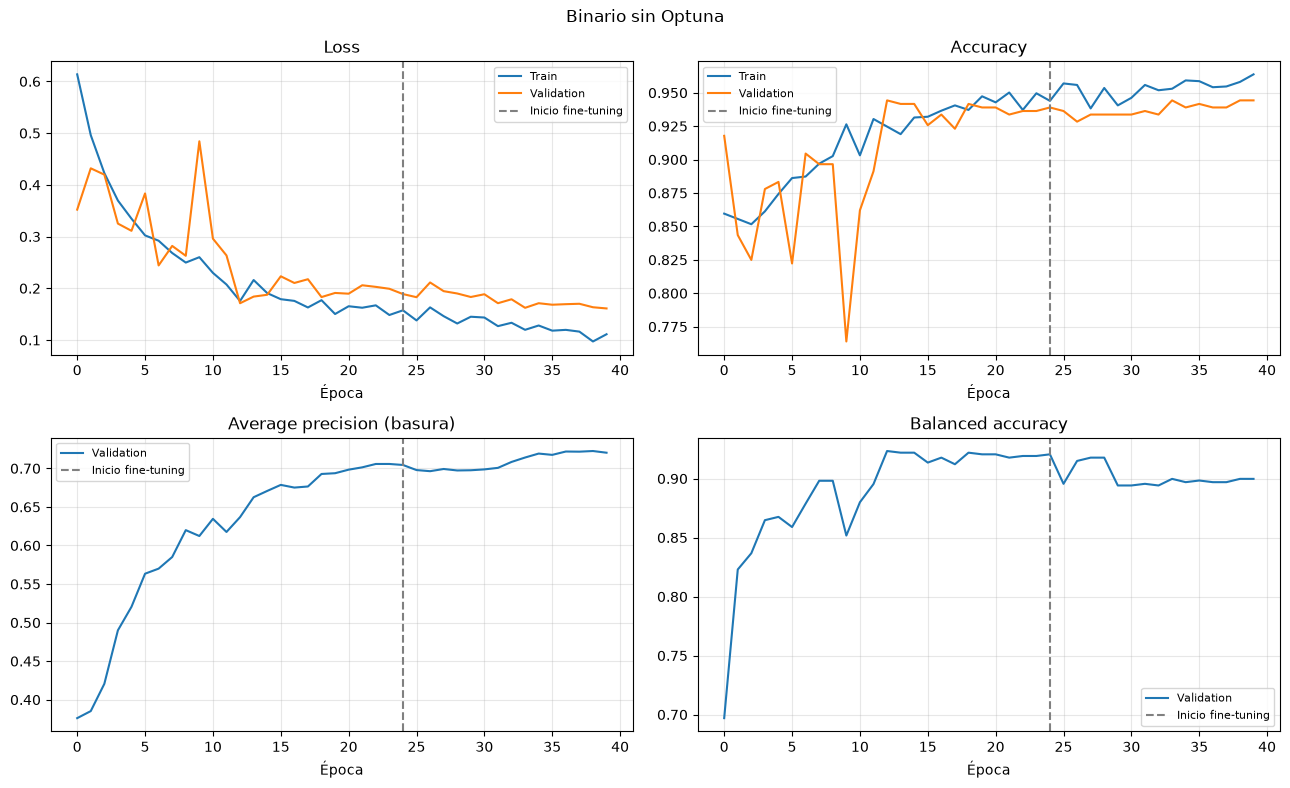

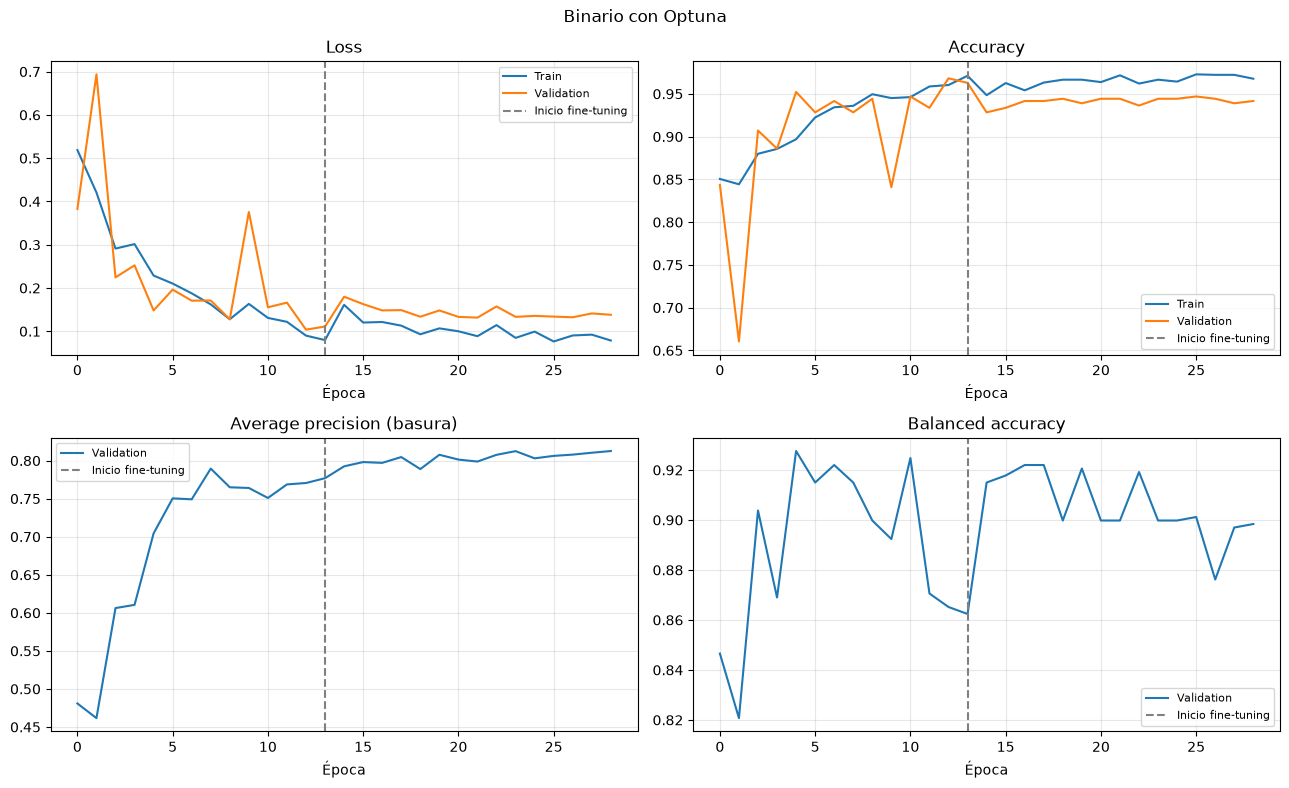

Fíjate en el panel de accuracy: se queda plano cerca de 0.95 desde el principio
y no distingue nada. Ese es el motivo de monitorizar la AP y no la accuracy.


In [27]:
# 24. Curvas de entrenamiento

def unir_historiales(h1, h2):
    claves = ["accuracy", "val_accuracy", "loss", "val_loss",
              "val_balanced_accuracy", "val_ap"]
    r = {k: h1[k] + h2[k] for k in claves}
    r["inicio_fine_tuning"] = len(h1["accuracy"])
    return r


def graficar_curvas(hist, titulo, archivo=None):
    paneles = [
        ("loss", "val_loss", "Loss"),
        ("accuracy", "val_accuracy", "Accuracy"),
        (None, "val_ap", "Average precision (basura)"),
        (None, "val_balanced_accuracy", "Balanced accuracy"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    for ax, (tr, va, etiqueta) in zip(axes.ravel(), paneles):
        if tr:
            ax.plot(hist[tr], label=f"Train")
        ax.plot(hist[va], label="Validation")
        ax.axvline(hist["inicio_fine_tuning"] - 1, linestyle="--", color="gray",
                   label="Inicio fine-tuning")
        ax.set_title(etiqueta)
        ax.set_xlabel("Época")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(titulo)
    plt.tight_layout()
    if archivo:
        plt.savefig(os.path.join(RESULTS_DIR, archivo), dpi=120)
    plt.show()


hist_base = unir_historiales(history_base_fase1, history_base_fase2)
hist_optuna = unir_historiales(history_optuna_fase1, history_optuna_fase2)

graficar_curvas(hist_base, "Binario sin Optuna", "bin_curvas_sin_optuna.png")
graficar_curvas(hist_optuna, "Binario con Optuna", "bin_curvas_optuna.png")

print("Fíjate en el panel de accuracy: se queda plano cerca de 0.95 desde el principio")
print("y no distingue nada. Ese es el motivo de monitorizar la AP y no la accuracy.")

## Parte D — Evaluación fuera de distribución (Garbage Dataset)

Las 453 imágenes de rechazo de `dataset_gd/` **nunca se usaron para entrenar ni para
calibrar el umbral**. Son fotos reales, con fondo y contexto, tomadas con móviles, frente
a las fotos de estudio sobre fondo blanco de TrashNet.

Como todas son de clase `basura`, la única métrica calculable es el **recall**: qué
fracción detecta el modelo con el umbral ya fijado. No hay negativos, así que no se puede
medir precision.

La comparación relevante es **recall en el test de TrashNet (22 imágenes) contra recall
en GD (453 imágenes)**. Si se desploma, el modelo aprendió el estudio fotográfico y no el
objeto.

Como el 30% de las imágenes de GD tienen algún lado por debajo de 224 px y se escalan
hacia arriba, los resultados se desglosan por resolución para separar "no generaliza" de
"la imagen no se ve".

Imágenes evaluadas: 453
Umbral aplicado:    0.837 (el calibrado en validación de TrashNet)

Recall en test de TrashNet (22 imágenes): 0.8182
Recall en GD (453 imágenes):                0.1192
Caída:                                        -0.6990

P(basura) en GD — media 0.1660 | mediana 0.0037
                  p10 0.0000 | p90 0.9043


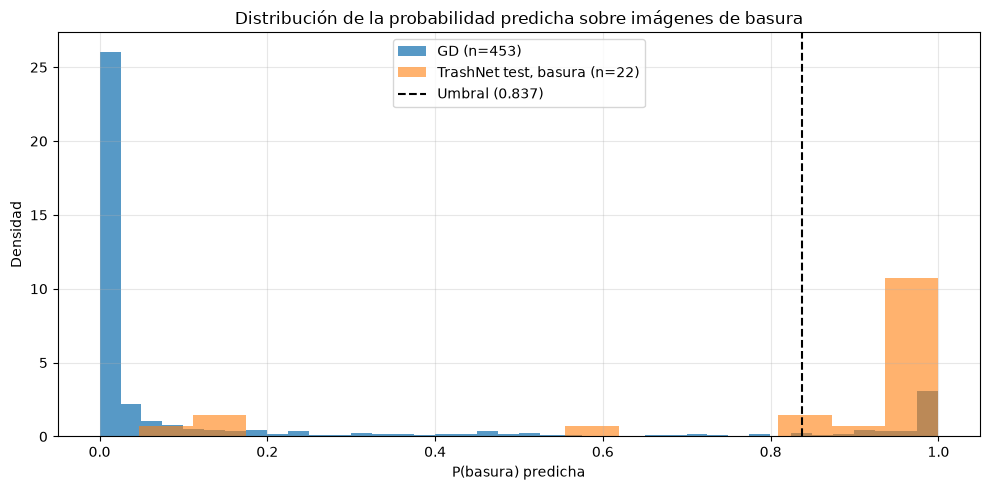

In [28]:
# 25. Evaluación sobre el Garbage Dataset

if not hay_gd:
    print(f"No existe {GD_DIR}/trash — Parte D omitida")
else:
    from PIL import Image

    gd_ds = datasets.ImageFolder(GD_DIR, transform=eval_tf)
    assert gd_ds.classes == ["trash"], f"Se esperaba solo 'trash': {gd_ds.classes}"

    gd_loader = DataLoader(gd_ds, batch_size=BATCH_SIZE, shuffle=False, **comun)

    model_optuna.eval()
    p_gd = []
    with torch.no_grad():
        for images, _ in gd_loader:
            probs = torch.softmax(model_optuna(images.to(DEVICE)), dim=1)
            p_gd.append(probs[:, IDX_BASURA].cpu().numpy())
    p_gd = np.concatenate(p_gd)

    recall_gd = float((p_gd >= UMBRAL).mean())
    recall_test = res_optuna["recall_basura"]

    print(f"Imágenes evaluadas: {len(p_gd)}")
    print(f"Umbral aplicado:    {UMBRAL:.3f} (el calibrado en validación de TrashNet)")
    print()
    print(f"Recall en test de TrashNet ({int(b_test.sum())} imágenes): {recall_test:.4f}")
    print(f"Recall en GD ({len(p_gd)} imágenes):                {recall_gd:.4f}")
    print(f"Caída:                                        {recall_gd - recall_test:+.4f}")
    print()
    print(f"P(basura) en GD — media {p_gd.mean():.4f} | mediana {np.median(p_gd):.4f}")
    print(f"                  p10 {np.percentile(p_gd, 10):.4f} | "
          f"p90 {np.percentile(p_gd, 90):.4f}")

    plt.figure(figsize=(10, 5))
    plt.hist(p_gd, bins=40, alpha=0.75, label=f"GD (n={len(p_gd)})", density=True)
    plt.hist(p_test_optuna[b_test == 1], bins=15, alpha=0.6,
             label=f"TrashNet test, basura (n={int(b_test.sum())})", density=True)
    plt.axvline(UMBRAL, linestyle="--", color="black", label=f"Umbral ({UMBRAL:.3f})")
    plt.xlabel("P(basura) predicha")
    plt.ylabel("Densidad")
    plt.title("Distribución de la probabilidad predicha sobre imágenes de basura")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "bin_gd_distribucion.png"), dpi=120)
    plt.show()

grupo                                n    recall   P(basura) media
------------------------------------------------------------------
lado menor < 224 (se agranda)      136    0.0074            0.0481
lado menor >= 224 (se reduce)      317    0.1672            0.2166
TOTAL                              453    0.1192            0.1660

Si el recall del grupo de alta resolución también es bajo, el problema es
el cambio de dominio (fondo y contexto), no la calidad de la imagen.


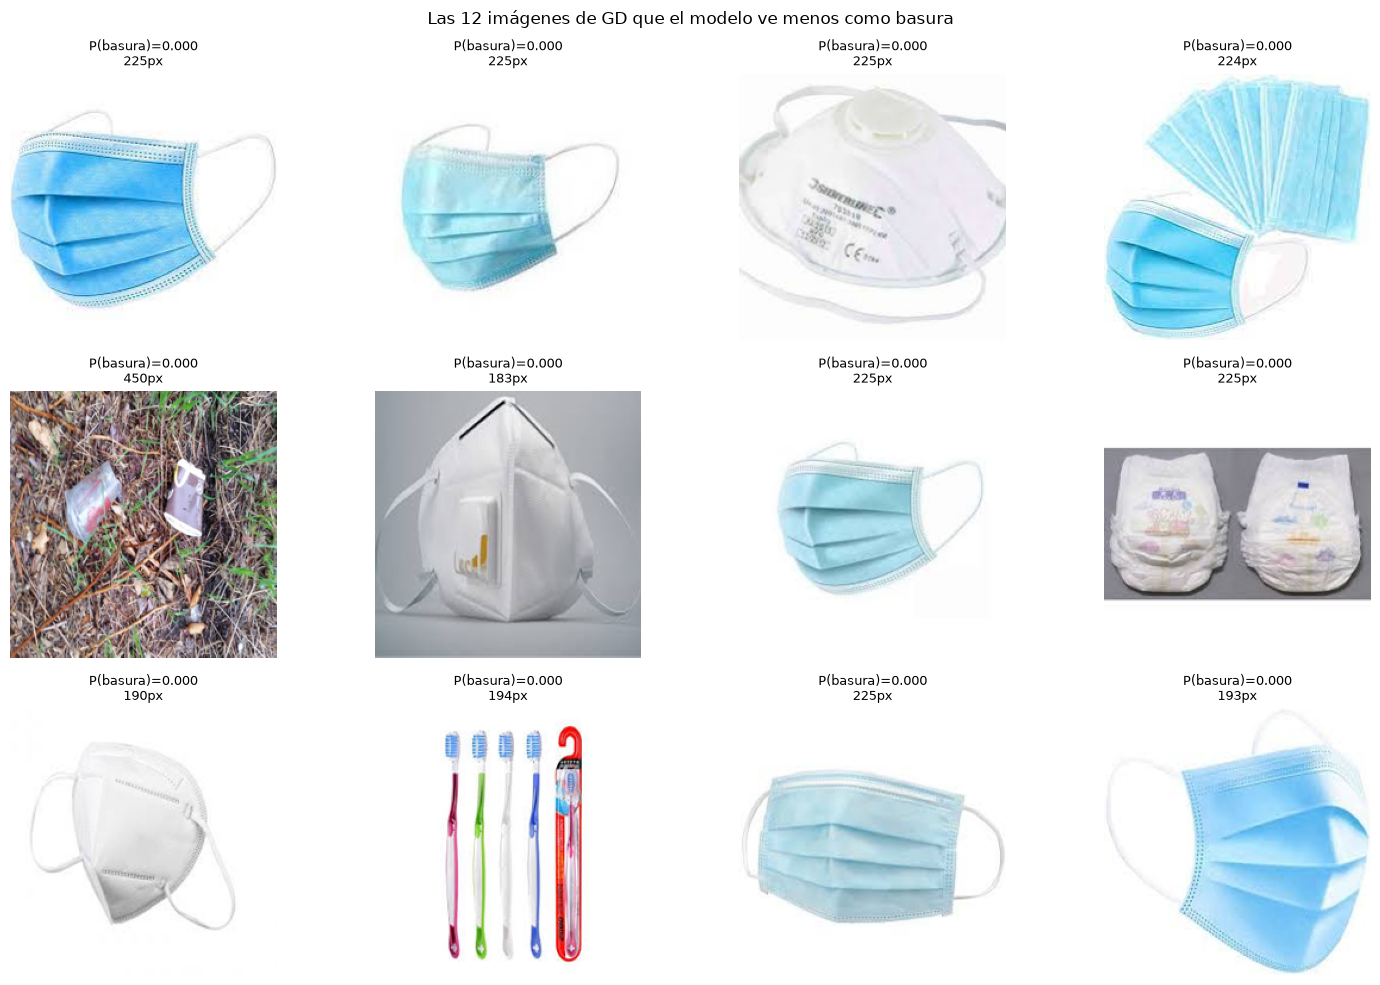

In [29]:
# 26. Desglose del resultado en GD por resolución
#     136 de las 453 imágenes tienen algún lado < 224 px y se escalan hacia arriba.

if not hay_gd:
    print("Parte D omitida")
else:
    lados_min = []
    for ruta, _ in gd_ds.samples:
        with Image.open(ruta) as im:
            lados_min.append(min(im.size))
    lados_min = np.array(lados_min)

    grupos = [
        ("lado menor < 224 (se agranda)", lados_min < 224),
        ("lado menor >= 224 (se reduce)", lados_min >= 224),
    ]

    print(f"{'grupo':<32}{'n':>6}{'recall':>10}{'P(basura) media':>18}")
    print("-" * 66)
    for nombre, mascara in grupos:
        if mascara.sum() == 0:
            continue
        print(f"{nombre:<32}{int(mascara.sum()):>6}"
              f"{float((p_gd[mascara] >= UMBRAL).mean()):>10.4f}"
              f"{float(p_gd[mascara].mean()):>18.4f}")
    print(f"{'TOTAL':<32}{len(p_gd):>6}{recall_gd:>10.4f}{float(p_gd.mean()):>18.4f}")

    print("\nSi el recall del grupo de alta resolución también es bajo, el problema es")
    print("el cambio de dominio (fondo y contexto), no la calidad de la imagen.")

    # Las 12 imágenes peor clasificadas, para inspección visual
    peores = np.argsort(p_gd)[:12]
    plt.figure(figsize=(15, 10))
    for k, idx in enumerate(peores):
        ruta = gd_ds.samples[idx][0]
        with Image.open(ruta) as im:
            plt.subplot(3, 4, k + 1)
            plt.imshow(im.convert("RGB").resize((224, 224)))
        plt.title(f"P(basura)={p_gd[idx]:.3f}\n{min(Image.open(ruta).size)}px",
                  fontsize=9)
        plt.axis("off")
    plt.suptitle("Las 12 imágenes de GD que el modelo ve menos como basura")
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "bin_gd_peores.png"), dpi=120)
    plt.show()

In [30]:
# 27. Resumen final

print("=" * 78)
print("RESUMEN FINAL — TRASHNET BINARIO RECICLABLE / BASURA (PYTORCH)")
print("=" * 78)

print("\nDATASET")
print(f"- Train: {sum(train_count.values())} ({train_count['basura']} basura, "
      f"{train_count['reciclable']} reciclable)")
print(f"- Validation: {sum(valid_count.values())} ({valid_count['basura']} basura)")
print(f"- Test: {sum(test_count.values())} ({test_count['basura']} basura)")
print(f"- Desbalance en train: {train_count['reciclable'] / train_count['basura']:.1f}:1")
print(f"- Dispositivo: {DEVICE}")

print("\nBÚSQUEDA CON OPTUNA")
print(f"- Métrica optimizada: average precision sobre '{CLASSES[IDX_BASURA]}'")
print(f"- Trials: {OPTUNA_TRIALS} ({OPTUNA_STARTUP_TRIALS} azar + "
      f"{OPTUNA_TRIALS - OPTUNA_STARTUP_TRIALS} TPE)")
print(f"- Baseline encolado (trial 0): AP {valor_baseline:.4f}")
print(f"- Mejor trial de búsqueda: {study.best_trial.number} (AP {study.best_value:.4f})")
print(f"- Ganador tras reentrenar el top-{TOP_K}: trial {BEST_TRIAL} ({ganador['fuente']})")
print(f"- Config: dense {BEST_DENSE_UNITS} | dropout {BEST_DROPOUT} | "
      f"lr {BEST_LR:.8f} | {BEST_OPTIMIZER}")

print("\nUMBRAL")
print(f"- Calibrado en validación: {UMBRAL:.3f} (argmax habría usado 0.500)")
print(f"- Ganancia de F1 por calibrar: "
      f"{m_f1['f1_basura'] - m_05['f1_basura']:+.4f} (en validación)")

print("\nTEST — CLASE BASURA")
print(f"- Precision: {res_optuna['precision_basura']:.4f}")
print(f"- Recall:    {res_optuna['recall_basura']:.4f}")
print(f"- F1:        {res_optuna['f1_basura']:.4f}")
print(f"- AP:        {test_optuna['ap']:.4f}")
print(f"- Accuracy:  {res_optuna['accuracy']:.4f} "
      f"(el trivial saca {BASELINE_TRIVIAL:.4f})")
print(f"- Balanced accuracy: {res_optuna['balanced_accuracy']:.4f}")

print("\nCOMPARACIÓN CON LOS BASELINES (F1 sobre basura)")
print(f"- Trivial 'todo reciclable': 0.0000")
print(f"- Jerárquico (clase gris):   {JERARQUICO_GRIS['f1_basura']:.4f}")
print(f"- Binario con Optuna:        {res_optuna['f1_basura']:.4f} "
      f"({res_optuna['f1_basura'] - JERARQUICO_GRIS['f1_basura']:+.4f})")

if hay_gd:
    print("\nFUERA DE DISTRIBUCIÓN (Garbage Dataset)")
    print(f"- Imágenes: {len(p_gd)}")
    print(f"- Recall en TrashNet test: {res_optuna['recall_basura']:.4f}")
    print(f"- Recall en GD:            {recall_gd:.4f}")
    print(f"- Caída:                   {recall_gd - res_optuna['recall_basura']:+.4f}")

print("\nARCHIVOS")
print(f"- Modelo sin Optuna: {RUTA_MODELO_BASE}")
print(f"- Modelo con Optuna: {RUTA_MODELO_OPTUNA}")
print(f"- Figuras: {RESULTS_DIR}/bin_*.png")
print("=" * 78)

RESUMEN FINAL — TRASHNET BINARIO RECICLABLE / BASURA (PYTORCH)

DATASET
- Train: 1766 (95 basura, 1671 reciclable)
- Validation: 377 (20 basura)
- Test: 384 (22 basura)
- Desbalance en train: 17.6:1
- Dispositivo: cuda

BÚSQUEDA CON OPTUNA
- Métrica optimizada: average precision sobre 'basura'
- Trials: 30 (10 azar + 20 TPE)
- Baseline encolado (trial 0): AP 0.5851
- Mejor trial de búsqueda: 18 (AP 0.8011)
- Ganador tras reentrenar el top-3: trial 21 (tpe)
- Config: dense 256 | dropout 0.25 | lr 0.00099466 | adam

UMBRAL
- Calibrado en validación: 0.837 (argmax habría usado 0.500)
- Ganancia de F1 por calibrar: +0.1429 (en validación)

TEST — CLASE BASURA
- Precision: 0.8182
- Recall:    0.8182
- F1:        0.8182
- AP:        0.7977
- Accuracy:  0.9792 (el trivial saca 0.9427)
- Balanced accuracy: 0.9036

COMPARACIÓN CON LOS BASELINES (F1 sobre basura)
- Trivial 'todo reciclable': 0.0000
- Jerárquico (clase gris):   0.7170
- Binario con Optuna:        0.8182 (+0.1012)

FUERA DE DISTRI

## Interpretación

### Cómo leer estos resultados

**El accuracy no significa nada aquí.** Cualquier número cerca de 0.94 puede ser un
modelo que no detecta ninguna basura. Las métricas que importan son F1 y AP sobre la
clase `basura`, y la balanced accuracy, que para el modelo trivial vale 0.5.

**La AUC va a ser mucho más alta que la AP.** No es una contradicción: con un 5.7% de
positivos, la tasa de falsos positivos apenas se mueve aunque el modelo produzca muchos
falsos positivos en términos absolutos. La curva PR sí lo refleja. Bajo desbalance
fuerte, reportar solo la AUC es engañoso y conviene explicarlo en el informe.

**El umbral es un resultado, no un detalle.** La diferencia entre `argmax` y el umbral
calibrado suele ser mayor que la diferencia entre modelos. Y es una decisión de producto:
un umbral bajo detecta más basura a costa de mandar reciclables al vertedero, uno alto
hace lo contrario. En este dominio el error caro suele ser dejar basura en el flujo de
reciclaje, porque contamina el lote entero.

### Los límites de este experimento

- **95 imágenes de basura en train.** Es muy poco, y el modelo puede estar memorizándolas
  en vez de aprender la categoría.
- **20 imágenes de basura en validación.** El umbral se calibra sobre 20 ejemplos: un
  acierto o fallo mueve el recall 5 puntos. El umbral elegido es ruidoso, y eso hay que
  decirlo. Una alternativa más sólida sería validación cruzada de 5 folds solo para elegir
  el umbral.
- **22 imágenes de basura en test.** Todas las métricas de esta clase tienen esa
  incertidumbre detrás. Por eso la Parte D, con 453 imágenes, es la evidencia más fuerte
  del notebook aunque solo mida recall.

### Qué hacer con el resultado de la Parte D

- **Si el recall en GD se desploma** (por debajo de ~0.5): el modelo aprendió el estudio
  fotográfico de TrashNet, no la categoría. Es una conclusión legítima y valiosa sobre los
  límites del dataset del proyecto, y no invalida los otros tres modelos — solo delimita
  hasta dónde se pueden extrapolar.
- **Si aguanta** (por encima de ~0.7): tienes un modelo demostrablemente robusto, que es
  bastante más de lo que se puede afirmar de los otros tres, ninguno evaluado fuera de su
  dataset.
- **Si el desglose por resolución muestra** que solo falla en las imágenes pequeñas, el
  problema es de calidad de imagen y no de dominio.